In [45]:
import autograd.numpy as np  # Import wrapped NumPy from autograd
from autograd import grad    # Import grad function to compute gradients
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

n = 10
m = 5


A = np.random.uniform(-10, 2, (m,n))
At = A.transpose()
K = np.random.uniform(-10, 2, (m,n)).transpose()

true_x = np.random.rand(n,n)
y = A@true_x

def f(x):
    return 0.5 * np.linalg.norm(A@x-y)**2

# Compute the gradient of f using autograd
grad_f_autodiff = grad(f)

def mm_grad_f(K, x):
    return K@(A@x - y)

def grad_f(x):
    return At@(A@x - y)

# Nuclear norm lmo
def lmo(gradient, rad):
    # Compute the leading singular vectors of gradient
    u1, sigma, vt1 = svds(gradient, k=1, which='LM')
    return -rad*(u1 @ vt1)

iterations = range(100000)

x = np.zeros((n,n))
objective_values = []
fw_gaps = []

t = 0

Kclose = (1-t)*At + t*K

radius = 5

tau = 2.0

eta = 0.9

In [46]:
eps = 1e-3
s = lmo(mm_grad_f(Kclose, x), radius)
M = np.linalg.norm(mm_grad_f(Kclose, x) - mm_grad_f(Kclose, x+eps*(s-x)))/(eps*np.linalg.norm(s-x))


for i in tqdm(iterations, desc='Optimizing', unit='iteration'):
    # Compute gradient at current point
    gradient = mm_grad_f(Kclose, x)
    # Compute LMO at current gradient
    s = lmo(gradient, radius)
    d = s-x
    g = (-gradient * d).sum()
    
    # Begin backtracking line-search
    M = eta * M
    step_size = np.min([1., g/(M * np.linalg.norm(d)**2)])
    while f(x + step_size * d) > (f(x) - step_size * g + (step_size ** 2 * M)/2 * np.linalg.norm(d)**2):
        M = tau * M
    # End of backtracking
    
    
    # Compute the real s
    real_s = lmo(grad_f(x), radius)
    # Compute the FW gap
    fw_gap = (grad_f(x) * (x - real_s)).sum()    
    # Perform the step
    x = x + step_size*(s-x)
    # Store the convergence info
    fw_gaps.append(fw_gap)
    objective_values.append(f(x))

Optimizing:   0%|          | 0/100000 [00:00<?, ?iteration/s]

0.0


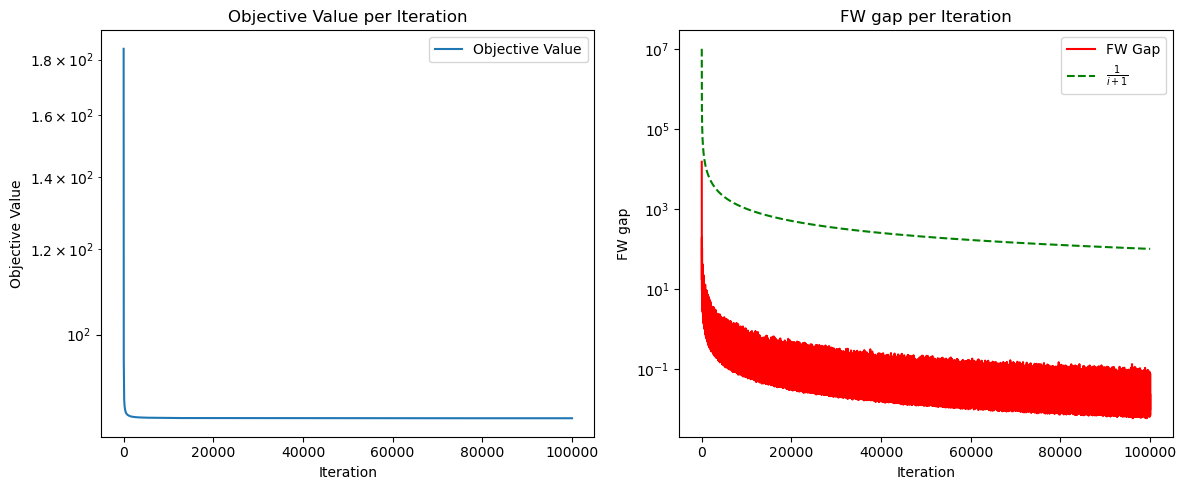

In [47]:
print(np.linalg.norm(Kclose-At, ord=2))

# Compute the theoretical convergence rate
theoretical_rate = [1e7/(i+1) for i in iterations]

# Create a figure with a 1x2 grid of subplots
plt.figure(figsize=(12, 5))

# Plotting the original objective values
plt.subplot(1, 2, 1)
#plt.plot(iterations, theoretical_rate, linestyle='--', color='g', label=r'$\frac{1}{i+1}$')
plt.plot(iterations, objective_values, label='Objective Value')
plt.yscale('log')
plt.title('Objective Value per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Objective Value')
plt.legend()

# Plotting the original FW gaps
plt.subplot(1, 2, 2)
plt.plot(iterations, fw_gaps, color='r', label='FW Gap')
plt.plot(iterations, theoretical_rate, linestyle='--', color='g', label=r'$\frac{1}{i+1}$')
plt.yscale('log')
plt.title('FW gap per Iteration')
plt.xlabel('Iteration')
plt.ylabel('FW gap')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def run_frank_wolfe(Kclose):
    objective_values = []
    x = np.zeros((n,n))
    for i in range(num_iterations):
        step_size = 1./(i+1)
        #closeness = 1./(i+1)
        #Kclose = (1-closeness)*At + closeness*K
        gradient = mm_grad_f(Kclose, x)
        #gradient = grad_f(x)
        s = lmo(gradient, 10)
        real_s = lmo(grad_f(x), 10)
        # Compute the FW gap
        fw_gap = (grad_f(x) * (x - real_s)).sum()
        #fw_gap = (gradient * (x-s)).sum()
        # Store the FW gap
        fw_gaps.append(fw_gap)
        x = x + step_size*(s-x)
        objective_values.append(f(x))
    return objective_values
    

# Setup: Number of iterations, matrices, etc.
num_iterations = 5000
num_matrices = 180

# Create a figure and axis
fig, ax = plt.subplots()


# Example: Determine the global maximum objective value for consistent y-axis
global_max = 0
for i in tqdm(range(num_matrices), desc='Getting global max', unit='iteration'):
    t = 0.01 + (0.3 - 0.01) * (i - 1) / (num_matrices - 1)
    print(t)
    
    # Generate or select your matrix Kclose here
    # Example: Kclose = np.random.randn(*desired_shape)
    Kclose = (1-t)*At + t*K
    
    # Run the algorithm and get objective values
    objective_values = run_frank_wolfe(Kclose)
    
    # Update global_max if needed
    current_max = np.max(objective_values)
    if current_max > global_max:
        global_max = current_max
        
# Example: Run Frank-Wolfe for different matrices and plot
for i in tqdm(range(num_matrices), desc='Saving figures', unit='iteration'):
    # Generate or select your matrix Kclose here
    t = 0.01 + (0.3 - 0.01) * (i - 1) / (num_matrices - 1)
    
    # Run the algorithm and get objective values
    objective_values = run_frank_wolfe(Kclose)
    
    # Plot
    ax.clear()  # Clear previous plots
    ax.plot(objective_values, label=f'Run {i+1}')
    
    # Customize your plot: labels, title, legend, etc.
    ax.set_title('Objective Values per Iteration')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Objective Value')
    ax.set_yscale('log')
    ax.legend()
    
    # Ensure the plots are consistent in terms of scale
    ax.set_xlim([0, num_iterations])
    ax.set_ylim([1e-2, global_max])
    
    # Save the plot as an image file
    plt.savefig(f'mm_fw_plots/plot_{i}.png')


In [ ]:
import imageio

num_matrices = 180  # or however many images you have
image_files = [f"mm_fw_plots/plot_{i}.png" for i in range(num_matrices)]  # adjust path and file naming as per your saved files

# Create a writer object
writer = imageio.get_writer("mm_fw_plots/animation.mp4", fps=15)

# Add frames to the animation
for image_file in image_files:
    image = imageio.imread(image_file)
    writer.append_data(image)

# Close the writer to save the video
writer.close()
